### Objective
To implement Dijkstra’s algorithm for finding the shortest path in a weighted graph and analyze its performance using different priority queue implementations (e.g., list-based and heap-based).

### Problem Statement
Implement Dijkstra’s algorithm using two types of priority queues: a list and a heap. Analyze and compare their runtime performance using test graphs.


### Equipment Required
- Python installed with Jupyter Notebook
- Libraries: `heapq`, `time`, `matplotlib`


### Prerequisites
- Basic understanding of graphs and shortest path algorithms
- Familiarity with Python programming
- Knowledge of priority queues and their time complexities

In [ ]:
### Step 1: Import Required Libraries

import heapq
import time
import random
import matplotlib.pyplot as plt


In [5]:

### Step 2: Graph Representation

def generate_graph(num_nodes, num_edges):
    graph = {i: [] for i in range(num_nodes)}
    for _ in range(num_edges):
        u = random.randint(0, num_nodes - 1)
        v = random.randint(0, num_nodes - 1)
        if u != v:
            weight = random.randint(1, 10)
            graph[u].append((v, weight))
            graph[v].append((u, weight))  # For undirected graph
    return graph

In [6]:
### Step 3: Dijkstra’s Algorithm with List-Based Priority Queue

def dijkstra_list(graph, start):
    visited = set()
    distance = {node: float('inf') for node in graph}
    distance[start] = 0
    queue = [(0, start)]

    while queue:
        queue.sort()  # Sort every time
        dist, node = queue.pop(0)
        if node in visited:
            continue
        visited.add(node)

        for neighbor, weight in graph[node]:
            if distance[node] + weight < distance[neighbor]:
                distance[neighbor] = distance[node] + weight
                queue.append((distance[neighbor], neighbor))

    return distance

In [7]:
### Step 4: Dijkstra’s Algorithm with Heap-Based Priority Queue

def dijkstra_heap(graph, start):
    visited = set()
    distance = {node: float('inf') for node in graph}
    distance[start] = 0
    heap = [(0, start)]

    while heap:
        dist, node = heapq.heappop(heap)
        if node in visited:
            continue
        visited.add(node)

        for neighbor, weight in graph[node]:
            if distance[node] + weight < distance[neighbor]:
                distance[neighbor] = distance[node] + weight
                heapq.heappush(heap, (distance[neighbor], neighbor))

    return distance

In [11]:
### Step 5: Display Dijkstra’s Output

graph = generate_graph(6, 10)
print("Sample Graph:", graph)
print("\nDijkstra with List-based Priority Queue:")
print(dijkstra_list(graph, 0))
print("\nDijkstra with Heap-based Priority Queue:")
print(dijkstra_heap(graph, 0))

Sample Graph: {0: [(2, 8), (3, 9), (4, 9)], 1: [], 2: [(0, 8), (3, 6), (3, 8), (3, 3)], 3: [(2, 6), (2, 8), (0, 9), (2, 3)], 4: [(0, 9)], 5: []}

Dijkstra with List-based Priority Queue:
{0: 0, 1: inf, 2: 8, 3: 9, 4: 9, 5: inf}

Dijkstra with Heap-based Priority Queue:
{0: 0, 1: inf, 2: 8, 3: 9, 4: 9, 5: inf}


In [12]:
### Step 6: Performance Analysis

sizes = [100, 200, 300, 400, 500]
list_times = []
heap_times = []

for size in sizes:
    graph = generate_graph(size, size * 3)

    start_time = time.time()
    dijkstra_list(graph, 0)
    list_times.append(time.time() - start_time)

    start_time = time.time()
    dijkstra_heap(graph, 0)
    heap_times.append(time.time() - start_time)


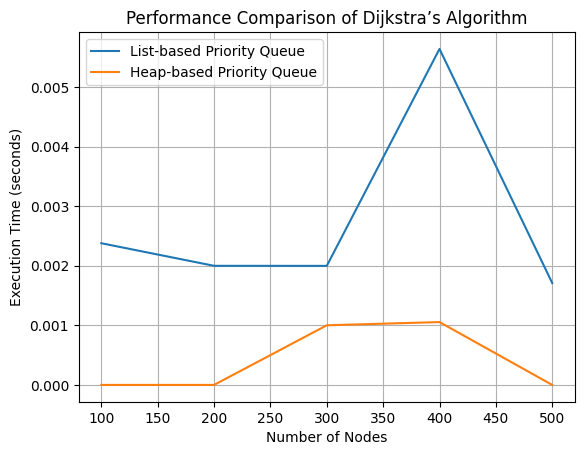

In [13]:
### Step 7: Plotting the Results

plt.plot(sizes, list_times, label='List-based Priority Queue')
plt.plot(sizes, heap_times, label='Heap-based Priority Queue')
plt.xlabel('Number of Nodes')
plt.ylabel('Execution Time (seconds)')
plt.title('Performance Comparison of Dijkstra’s Algorithm')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion
This lab demonstrates the significance of data structure choices in algorithm performance. Heap-based priority queues outperform list-based ones, especially on larger graphs, due to better time complexity for insertion and extraction.
